# DBA5106 Project 1 - Stock Returns

## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import Lasso, LassoCV, Ridge, RidgeCV
from sklearn.model_selection import KFold
import warnings

## Data Exploration

### Preliminary Processing

In [ ]:
DATA_PATH = os.path.join("..", "data", "100_Portfolios_10x10_Daily.csv")

raw_df = pd.read_csv(DATA_PATH, skiprows=26318, nrows=26296)
raw_df.head()

,Unnamed: 0,SMALL LoBM,ME1 BM2,ME1 BM3,ME1 BM4,ME1 BM5,ME1 BM6,ME1 BM7,ME1 BM8,ME1 BM9,...,BIG LoBM,ME10 BM2,ME10 BM3,ME10 BM4,ME10 BM5,ME10 BM6,ME10 BM7,ME10 BM8,ME10 BM9,BIG HiBM
0,19260701,-99.99,0.00,-99.99,1.59,-3.13,4.32,2.55,8.90,0.00,...,-0.02,0.24,0.11,0.00,0.09,0.51,-0.09,-0.34,0.17,-99.99
1,19260702,-99.99,-0.66,-99.99,0.00,-1.42,-4.11,0.30,-0.58,2.82,...,0.43,0.73,1.20,0.81,0.68,0.27,0.24,0.34,0.34,-99.99
2,19260706,-99.99,0.87,-99.99,-4.69,2.74,-1.58,0.00,2.36,-5.90,...,0.47,0.04,0.67,0.32,-0.19,-0.05,-0.18,-0.51,-0.34,-99.99
3,19260707,-99.99,-1.43,-99.99,4.92,0.60,6.07,0.00,-1.86,-0.03,...,-0.18,-0.06,0.89,0.35,0.04,0.16,0.09,0.51,0.17,-99.99
4,19260708,-99.99,0.00,-99.99,1.56,-0.59,-0.54,0.00,7.25,0.89,...,0.64,-0.05,1.14,0.71,0.01,0.20,0.30,0.34,0.51,-99.99


In [3]:
df = raw_df.rename(columns={"Unnamed: 0": "date"})
df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")

# Drop columns with missing data
df = df.drop(columns=["ME9 BM10", "BIG HiBM"])
df.head()

,date,SMALL LoBM,ME1 BM2,ME1 BM3,ME1 BM4,ME1 BM5,ME1 BM6,ME1 BM7,ME1 BM8,ME1 BM9,...,ME9 BM9,BIG LoBM,ME10 BM2,ME10 BM3,ME10 BM4,ME10 BM5,ME10 BM6,ME10 BM7,ME10 BM8,ME10 BM9
0,1926-07-01,-99.99,0.00,-99.99,1.59,-3.13,4.32,2.55,8.90,0.00,...,0.56,-0.02,0.24,0.11,0.00,0.09,0.51,-0.09,-0.34,0.17
1,1926-07-02,-99.99,-0.66,-99.99,0.00,-1.42,-4.11,0.30,-0.58,2.82,...,0.15,0.43,0.73,1.20,0.81,0.68,0.27,0.24,0.34,0.34
2,1926-07-06,-99.99,0.87,-99.99,-4.69,2.74,-1.58,0.00,2.36,-5.90,...,1.19,0.47,0.04,0.67,0.32,-0.19,-0.05,-0.18,-0.51,-0.34
3,1926-07-07,-99.99,-1.43,-99.99,4.92,0.60,6.07,0.00,-1.86,-0.03,...,3.35,-0.18,-0.06,0.89,0.35,0.04,0.16,0.09,0.51,0.17
4,1926-07-08,-99.99,0.00,-99.99,1.56,-0.59,-0.54,0.00,7.25,0.89,...,0.00,0.64,-0.05,1.14,0.71,0.01,0.20,0.30,0.34,0.51


In [ ]:
# We wish to vary window size later, to a maximum of 252 days. So select rows such that the first row is
# 252 days before first val day
rows_before_first_val_day = 252
first_val_idx = df.index[df["date"] == "2026-01-02"][0]

df = df.iloc[first_val_idx - rows_before_first_val_day:].reset_index(drop=True)
df.head()

,date,SMALL LoBM,ME1 BM2,ME1 BM3,ME1 BM4,ME1 BM5,ME1 BM6,ME1 BM7,ME1 BM8,ME1 BM9,...,ME9 BM9,BIG LoBM,ME10 BM2,ME10 BM3,ME10 BM4,ME10 BM5,ME10 BM6,ME10 BM7,ME10 BM8,ME10 BM9
0,2024-12-30,1.86,1.27,9.33,1.70,-0.04,0.22,-0.75,-0.37,0.74,...,-0.73,-1.19,-1.24,-1.24,-1.04,-0.38,-1.26,-0.76,-0.75,-1.02
1,2024-12-31,-0.86,-1.06,-1.04,-0.17,-0.85,-1.03,-0.17,-1.28,-0.06,...,0.02,-0.40,-0.09,-0.13,0.14,0.62,0.64,0.60,0.50,0.19
2,2025-01-02,2.13,1.54,2.79,2.33,2.13,1.88,1.50,0.49,3.66,...,0.33,-0.24,-0.39,-0.15,0.58,0.14,0.42,0.23,-0.51,-0.17
3,2025-01-03,6.26,3.97,3.42,3.20,2.92,4.47,2.90,2.18,3.55,...,0.66,1.20,1.34,1.00,1.18,0.90,1.04,0.41,1.69,0.99
4,2025-01-06,1.33,2.05,1.60,-0.64,-0.26,0.03,1.48,0.66,0.36,...,0.97,-0.06,0.58,0.09,-0.03,-0.86,0.27,-1.05,-0.13,0.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392,2026-07-27,1.15,1.62,0.79,1.23,1.29,0.96,1.57,1.16,0.39,...,1.17,0.86,-0.04,0.29,0.88,-0.17,-0.81,0.19,2.35,1.48
393,2026-07-28,-1.55,-0.08,-1.18,-0.57,-1.00,-0.45,-0.97,0.59,-0.05,...,0.77,-0.17,-0.80,-0.55,1.22,-0.09,0.22,0.88,2.93,2.81
394,2026-07-29,-2.81,0.34,-2.65,-2.68,-2.31,-1.81,-3.13,-1.10,-1.74,...,-1.82,-1.53,-1.89,-1.64,-1.22,-1.39,-0.26,-1.58,-2.06,-1.15
395,2026-07-30,3.57,1.10,2.37,1.83,2.81,1.13,9.59,3.14,2.16,...,0.43,3.12,1.90,0.60,0.42,0.96,-0.33,0.68,-0.89,0.13


In [5]:
# Check for missing data. -99.99 and -999 both indicate missing data
df = df.replace([-99.99, -999], np.nan)

print("Total number of instances of missing data:", df.isna().sum().sum())

Total number of instances of missing data: 0


### EDA

In [6]:
# Portfolio return columns
return_cols = df.columns.drop("date")

print("Shape:", df.shape)
print("Start date:", df["date"].min())
print("End date:", df["date"].max())
print("Number of portfolios:", len(return_cols))
print("Duplicate dates:", df["date"].duplicated().sum())

Shape: (397, 99)
Start date: 2024-12-30 00:00:00
End date: 2026-07-31 00:00:00
Number of portfolios: 98
Duplicate dates: 0


In [7]:
summary = df[return_cols].describe().T
summary.head()

,count,mean,std,min,25%,50%,75%,max
SMALL LoBM,397.0,-0.001436,1.990286,-5.20,-1.25,0.11,1.42,7.40
ME1 BM2,397.0,0.079723,2.150020,-5.98,-1.24,0.16,1.55,8.90
ME1 BM3,397.0,0.083174,1.996525,-6.10,-1.07,0.05,1.32,10.55
ME1 BM4,397.0,0.123804,3.188597,-5.79,-1.23,-0.09,1.28,49.29
ME1 BM5,397.0,0.060403,2.033770,-6.11,-1.23,0.11,1.38,6.53


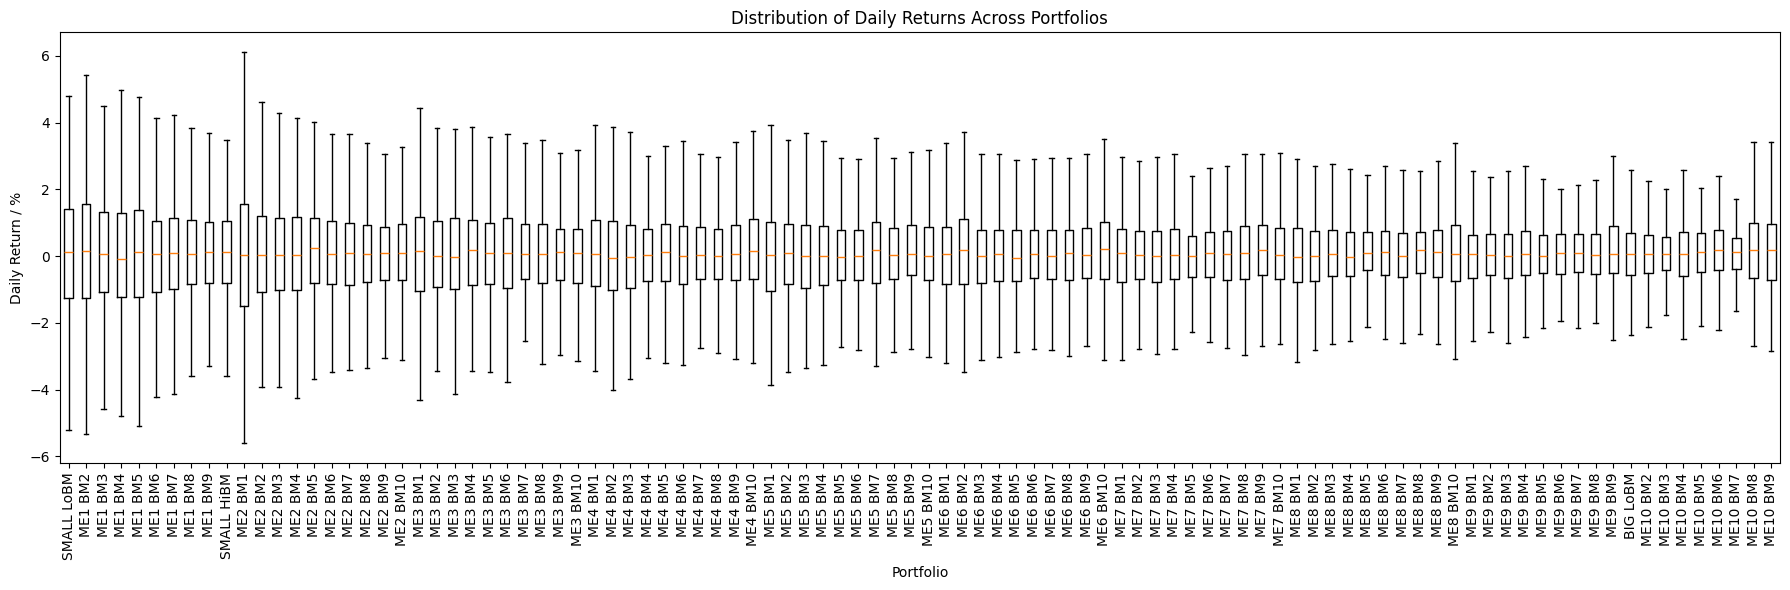

In [8]:
# Boxplot of daily returns by portfolio
plt.figure(figsize=(18, 6))

plt.boxplot(
    [df[col] for col in return_cols],
    tick_labels=return_cols,
    showfliers=False
)

plt.xticks(rotation=90)
plt.xlabel("Portfolio")
plt.ylabel("Daily Return / %")
plt.title("Distribution of Daily Returns Across Portfolios")
plt.tight_layout()
plt.show()

## Experiments

In [9]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [10]:
WEIGHTS_PATH = os.path.join("..", "weights")
os.makedirs(WEIGHTS_PATH, exist_ok=True)

### Helpers

In [11]:
def sharpe_ratio(returns):
    returns = np.asarray(returns)

    return np.mean(returns) / np.std(returns, ddof=1)


def cv_select(X, y, R, N, w_ew, model_type, lambdas, k, cv_method, seed):
    cv = KFold(n_splits=k, shuffle=True, random_state=seed)

    # Using L2 loss to pick best lambda. Can directly use RidgeCV and LassoCV for CV process
    if cv_method == "L2":
        # Ridge regularisation
        if model_type == "ridge":
            model = RidgeCV(
                alphas=lambdas,
                cv=cv,
                scoring="neg_mean_squared_error",
                fit_intercept=True
            )

        # LASSO regularisation
        elif model_type == "lasso":
            model = LassoCV(
                alphas=lambdas,
                cv=cv,
                fit_intercept=True,
                max_iter=100000
            )

        else:
            raise ValueError("model_type must be 'ridge' or 'lasso'")

        model.fit(X, y)

        return model.alpha_, model.coef_

    # Using Sharpe ratio to pick best lambda.
    # Need to do CV manually.
    # 2 ways to calculate Sharpe ratio for each lambda:
    # mean_sharpe: Get Sharpe ratio for each of the k iterations and calculate mean
    # pooled_sharpe: Pool all the validation returns and calculate a single Sharpe ratio
    elif cv_method in ["mean_sharpe", "pooled_sharpe"]:
        lambda_scores = []

        for lam in lambdas:
            sharpes_of_val_folds = []
            pooled_val_returns = []

            for train_idx, val_idx in cv.split(X):
                X_train = X[train_idx]
                y_train = y[train_idx]
                R_val = R[val_idx]

                if model_type == "ridge":
                    model = Ridge(
                        alpha=lam,
                        fit_intercept=True
                    )

                elif model_type == "lasso":
                    model = Lasso(
                        alpha=lam,
                        fit_intercept=True,
                        max_iter=100000
                    )

                else:
                    raise ValueError(
                        "model_type must be 'ridge' or 'lasso'"
                    )

                model.fit(X_train, y_train)

                beta = model.coef_
                w = w_ew - N @ beta

                val_returns = R_val @ w

                if cv_method == "mean_sharpe":
                    sharpes_of_val_folds.append(sharpe_ratio(val_returns))

                else:
                    pooled_val_returns.extend(val_returns)

            if cv_method == "mean_sharpe":
                score = np.mean(sharpes_of_val_folds)

            else:
                score = sharpe_ratio(np.asarray(pooled_val_returns))

            lambda_scores.append(score)

        best_lambda = lambdas[np.argmax(lambda_scores)]

        if model_type == "ridge":
            final_model = Ridge(
                alpha=best_lambda,
                fit_intercept=True
            )

        else:
            final_model = Lasso(
                alpha=best_lambda,
                fit_intercept=True,
                max_iter=100000
            )

        final_model.fit(X, y)

        return best_lambda, final_model.coef_

    raise ValueError(
        "cv_method must be 'L2', "
        "'mean_sharpe', or 'pooled_sharpe'"
    )


def fit_with_cv(R, model_type, lambdas, k, cv_method, seed):
    _, p = R.shape

    # Equal-weight portfolio
    w_ew = np.ones(p) / p

    # Construct N
    N = np.vstack([
        np.eye(p - 1),
        -np.ones(p - 1)
    ])

    # Construct regression
    y = R @ w_ew
    X = R @ N

    # Beta obtained by fitting entire set (train + val) using best lambda
    best_lambda, beta = cv_select(
        X=X,
        y=y,
        R=R,
        N=N,
        w_ew=w_ew,
        model_type=model_type,
        lambdas=lambdas,
        k=k,
        cv_method=cv_method,
        seed=seed
    )

    # Convert beta -> portfolio weights
    w = w_ew - N @ beta

    return w, best_lambda


def run_backtest(
    df,
    return_cols,
    model_type,
    window_size,
    first_val_date,
    last_val_date,
    cv_folds,
    lambdas,
    cv_method,
    seed
):
    start_idx = df.index[df["date"] == first_val_date][0]
    end_idx = df.index[df["date"] == last_val_date][0]

    selected_lambdas = []
    weights = []

    for i in range(start_idx, end_idx + 1):
        # Find previous trading days to make a window
        R_window = df.iloc[i - window_size: i][return_cols].to_numpy()

        # Train
        final_weights, best_lambda = fit_with_cv(
            R_window,
            model_type=model_type,
            lambdas=lambdas,
            k=cv_folds,
            cv_method=cv_method,
            seed=seed
        )

        print(f"Val day {i - start_idx + 1} / {end_idx - start_idx + 1} | Best lambda: {best_lambda}")

        selected_lambdas.append(best_lambda)
        weights.append(final_weights)

    return {
        "lambdas": np.array(selected_lambdas),
        "weights": np.array(weights)
    }


def evaluate(df, return_cols, weights, first_val_date, last_val_date):
    start_idx = df.index[df["date"] == first_val_date][0]
    end_idx = df.index[df["date"] == last_val_date][0]

    # Actual asset returns during validation period
    R_val = df.iloc[start_idx: end_idx + 1][return_cols].to_numpy(dtype=float)

    weights = np.asarray(weights)

    if R_val.shape != weights.shape:
        raise ValueError(
            f"R_val shape {R_val.shape} does not match weights shape {weights.shape}"
        )

    # One weight vector for each validation date
    # Portfolio return on day t = r_t @ w_t
    portfolio_returns = np.sum(R_val * weights, axis=1)
    sharpe = sharpe_ratio(portfolio_returns)

    return {
        "returns": portfolio_returns,
        "sharpe": sharpe
    }

### Hyperparameters

In [12]:
FIRST_VAL_DATE = pd.Timestamp("2026-01-02")
LAST_VAL_DATE = pd.Timestamp("2026-07-31")

CV_FOLDS = 5
CV_LAMBDAS = np.logspace(-8, 8, 101)
SEED = 42

### Indices of Validation Set

In [13]:
val_start_idx = df.index[df["date"] == FIRST_VAL_DATE][0]
val_end_idx = df.index[df["date"] == LAST_VAL_DATE][0]
val_dates = df.iloc[val_start_idx: val_end_idx + 1]["date"].values

### Trial 1
Equal weights used.

In [14]:
p = len(return_cols)
w_ew = np.ones(p) / p

# Find size of validation days
n_val_days = val_end_idx - val_start_idx + 1

# Assign the same vector w_ew to each validation day
ew_weight_matrix = np.tile(w_ew, (n_val_days, 1))

# Verify that the weights for each day sum to 1
print("Weights sum to 1:", np.allclose(ew_weight_matrix.sum(axis=1), 1))

ew_results = evaluate(
    df=df,
    return_cols=return_cols,
    weights=ew_weight_matrix,
    first_val_date=FIRST_VAL_DATE,
    last_val_date=LAST_VAL_DATE
)

Weights sum to 1: True


In [15]:
ew_results["sharpe"]

np.float64(0.11138588892127202)

### Trial 2
LASSO used for regularisation. Window size = 126, L2 loss used to pick best lambda.

In [16]:
lasso_126 = run_backtest(
    df=df,
    return_cols=return_cols,
    model_type="lasso",
    window_size=126,
    first_val_date=FIRST_VAL_DATE,
    last_val_date=LAST_VAL_DATE,
    cv_folds=CV_FOLDS,
    lambdas=CV_LAMBDAS,
    cv_method="L2",
    seed=SEED
)

lasso_126_weight_matrix = lasso_126["weights"]

# Verify that the weights for each day sum to 1
print("Weights sum to 1:", np.allclose(lasso_126_weight_matrix.sum(axis=1), 1))

Val day 1 / 145 | Best lambda: 0.017378008287493762
Val day 2 / 145 | Best lambda: 0.017378008287493762
Val day 3 / 145 | Best lambda: 0.017378008287493762
Val day 4 / 145 | Best lambda: 0.03630780547701017
Val day 5 / 145 | Best lambda: 0.025118864315095822
Val day 6 / 145 | Best lambda: 0.017378008287493762
Val day 7 / 145 | Best lambda: 0.012022644346174132
Val day 8 / 145 | Best lambda: 0.03630780547701017
Val day 9 / 145 | Best lambda: 0.03630780547701017
Val day 10 / 145 | Best lambda: 0.03630780547701017
Val day 11 / 145 | Best lambda: 0.025118864315095822
Val day 12 / 145 | Best lambda: 0.03630780547701017
Val day 13 / 145 | Best lambda: 0.012022644346174132
Val day 14 / 145 | Best lambda: 0.025118864315095822
Val day 15 / 145 | Best lambda: 0.025118864315095822
Val day 16 / 145 | Best lambda: 0.025118864315095822
Val day 17 / 145 | Best lambda: 0.03630780547701017
Val day 18 / 145 | Best lambda: 0.025118864315095822
Val day 19 / 145 | Best lambda: 0.03630780547701017
Val day 2

In [17]:
lasso_126_results = evaluate(
    df=df,
    return_cols=return_cols,
    weights=lasso_126_weight_matrix,
    first_val_date=FIRST_VAL_DATE,
    last_val_date=LAST_VAL_DATE
)

In [18]:
lasso_126_results["sharpe"]

np.float64(0.03720412960463627)

In [19]:
lasso_126_df = pd.DataFrame(
    lasso_126_weight_matrix,
    columns=return_cols
)

lasso_126_df.insert(0, "date", val_dates)

lasso_126_df.to_csv(
    os.path.join(WEIGHTS_PATH, "lasso_126_weights.csv"),
    index=False
)

### Trial 3
Ridge used for regularisation. Window size = 126, L2 loss used to pick best lambda.

In [20]:
ridge_126 = run_backtest(
    df=df,
    return_cols=return_cols,
    model_type="ridge",
    window_size=126,
    first_val_date=FIRST_VAL_DATE,
    last_val_date=LAST_VAL_DATE,
    cv_folds=CV_FOLDS,
    lambdas=CV_LAMBDAS,
    cv_method="L2",
    seed=SEED
)

ridge_126_weight_matrix = ridge_126["weights"]

# Verify that the weights for each day sum to 1
print("Weights sum to 1:", np.allclose(ridge_126_weight_matrix.sum(axis=1), 1))

Val day 1 / 145 | Best lambda: 27.542287033381633
Val day 2 / 145 | Best lambda: 39.81071705534969
Val day 3 / 145 | Best lambda: 27.542287033381633
Val day 4 / 145 | Best lambda: 39.81071705534969
Val day 5 / 145 | Best lambda: 39.81071705534969
Val day 6 / 145 | Best lambda: 19.054607179632445
Val day 7 / 145 | Best lambda: 19.054607179632445
Val day 8 / 145 | Best lambda: 27.542287033381633
Val day 9 / 145 | Best lambda: 39.81071705534969
Val day 10 / 145 | Best lambda: 27.542287033381633
Val day 11 / 145 | Best lambda: 27.542287033381633
Val day 12 / 145 | Best lambda: 27.542287033381633
Val day 13 / 145 | Best lambda: 9.120108393559116
Val day 14 / 145 | Best lambda: 27.542287033381633
Val day 15 / 145 | Best lambda: 27.542287033381633
Val day 16 / 145 | Best lambda: 27.542287033381633
Val day 17 / 145 | Best lambda: 27.542287033381633
Val day 18 / 145 | Best lambda: 27.542287033381633
Val day 19 / 145 | Best lambda: 19.054607179632445
Val day 20 / 145 | Best lambda: 19.0546071796

In [21]:
ridge_126_results = evaluate(
    df=df,
    return_cols=return_cols,
    weights=ridge_126_weight_matrix,
    first_val_date=FIRST_VAL_DATE,
    last_val_date=LAST_VAL_DATE
)

In [22]:
ridge_126_results["sharpe"]

np.float64(-0.006843167365814792)

In [23]:
ridge_126_df = pd.DataFrame(
    ridge_126_weight_matrix,
    columns=return_cols
)

ridge_126_df.insert(0, "date", val_dates)

ridge_126_df.to_csv(
    os.path.join(WEIGHTS_PATH, "ridge_126_weights.csv"),
    index=False
)

### Trial 4
LASSO used for regularisation. Window size = 126, Sharpe ratio used to pick best lambda. For a given lambda, calculate a Sharpe ratio for each validation fold before determining the mean Sharpe ratio.

In [24]:
lasso_126_mean_sharpe = run_backtest(
    df=df,
    return_cols=return_cols,
    model_type="lasso",
    window_size=126,
    first_val_date=FIRST_VAL_DATE,
    last_val_date=LAST_VAL_DATE,
    cv_folds=CV_FOLDS,
    lambdas=CV_LAMBDAS,
    cv_method="mean_sharpe",
    seed=SEED
)

lasso_126_mean_sharpe_weight_matrix = lasso_126_mean_sharpe["weights"]

# Verify that the weights for each day sum to 1
print("Weights sum to 1:", np.allclose(lasso_126_mean_sharpe_weight_matrix.sum(axis=1), 1))

Val day 1 / 145 | Best lambda: 0.6918309709189363
Val day 2 / 145 | Best lambda: 1e-08
Val day 3 / 145 | Best lambda: 0.002754228703338169
Val day 4 / 145 | Best lambda: 0.0003019951720402019
Val day 5 / 145 | Best lambda: 1e-08
Val day 6 / 145 | Best lambda: 1.0
Val day 7 / 145 | Best lambda: 0.0004365158322401656
Val day 8 / 145 | Best lambda: 0.0019054607179632482
Val day 9 / 145 | Best lambda: 0.0002089296130854041
Val day 10 / 145 | Best lambda: 1.0964781961431852e-05
Val day 11 / 145 | Best lambda: 0.003981071705534978
Val day 12 / 145 | Best lambda: 0.0004365158322401656
Val day 13 / 145 | Best lambda: 1e-08
Val day 14 / 145 | Best lambda: 0.0003019951720402019
Val day 15 / 145 | Best lambda: 0.0002089296130854041
Val day 16 / 145 | Best lambda: 0.0009120108393559096
Val day 17 / 145 | Best lambda: 0.0009120108393559096
Val day 18 / 145 | Best lambda: 0.0013182567385564075
Val day 19 / 145 | Best lambda: 0.22908676527677746
Val day 20 / 145 | Best lambda: 0.0019054607179632482
V

In [25]:
lasso_126_mean_sharpe_results = evaluate(
    df=df,
    return_cols=return_cols,
    weights=lasso_126_mean_sharpe_weight_matrix,
    first_val_date=FIRST_VAL_DATE,
    last_val_date=LAST_VAL_DATE
)

In [26]:
lasso_126_mean_sharpe_results["sharpe"]

np.float64(-0.05556740051526748)

In [27]:
lasso_126_mean_sharpe_df = pd.DataFrame(
    lasso_126_mean_sharpe_weight_matrix,
    columns=return_cols
)

lasso_126_mean_sharpe_df.insert(0, "date", val_dates)

lasso_126_mean_sharpe_df.to_csv(
    os.path.join(WEIGHTS_PATH, "lasso_126_mean_sharpe_weights.csv"),
    index=False
)

### Trial 5
Ridge used for regularisation. Window size = 126, Sharpe ratio used to pick best lambda. For a given lambda, calculate a Sharpe ratio for each validation fold before determining the mean Sharpe ratio.

In [28]:
ridge_126_mean_sharpe = run_backtest(
    df=df,
    return_cols=return_cols,
    model_type="ridge",
    window_size=126,
    first_val_date=FIRST_VAL_DATE,
    last_val_date=LAST_VAL_DATE,
    cv_folds=CV_FOLDS,
    lambdas=CV_LAMBDAS,
    cv_method="mean_sharpe",
    seed=SEED
)

ridge_126_mean_sharpe_weight_matrix = ridge_126_mean_sharpe["weights"]

# Verify that the weights for each day sum to 1
print("Weights sum to 1:", np.allclose(ridge_126_mean_sharpe_weight_matrix.sum(axis=1), 1))

Val day 1 / 145 | Best lambda: 39.81071705534969
Val day 2 / 145 | Best lambda: 6.309573444801943
Val day 3 / 145 | Best lambda: 27.542287033381633
Val day 4 / 145 | Best lambda: 0.1096478196143185
Val day 5 / 145 | Best lambda: 1e-08
Val day 6 / 145 | Best lambda: 131825.673855641
Val day 7 / 145 | Best lambda: 0.33113112148259144
Val day 8 / 145 | Best lambda: 1.0
Val day 9 / 145 | Best lambda: 0.1096478196143185
Val day 10 / 145 | Best lambda: 0.0019054607179632482
Val day 11 / 145 | Best lambda: 2.089296130854041
Val day 12 / 145 | Best lambda: 0.07585775750291836
Val day 13 / 145 | Best lambda: 1e-08
Val day 14 / 145 | Best lambda: 0.47863009232263803
Val day 15 / 145 | Best lambda: 0.1096478196143185
Val day 16 / 145 | Best lambda: 0.33113112148259144
Val day 17 / 145 | Best lambda: 0.47863009232263803
Val day 18 / 145 | Best lambda: 1.0
Val day 19 / 145 | Best lambda: 19.054607179632445
Val day 20 / 145 | Best lambda: 2.089296130854041
Val day 21 / 145 | Best lambda: 3.019951720

In [29]:
ridge_126_mean_sharpe_results = evaluate(
    df=df,
    return_cols=return_cols,
    weights=ridge_126_mean_sharpe_weight_matrix,
    first_val_date=FIRST_VAL_DATE,
    last_val_date=LAST_VAL_DATE
)

In [30]:
ridge_126_mean_sharpe_results["sharpe"]

np.float64(-0.003355272217381153)

In [31]:
ridge_126_mean_sharpe_df = pd.DataFrame(
    ridge_126_mean_sharpe_weight_matrix,
    columns=return_cols
)

ridge_126_mean_sharpe_df.insert(0, "date", val_dates)

ridge_126_mean_sharpe_df.to_csv(
    os.path.join(WEIGHTS_PATH, "ridge_126_mean_sharpe_weights.csv"),
    index=False
)

### Trial 6
LASSO used for regularisation. Window size = 126, Sharpe ratio used to pick best lambda. For a given lambda, pool returns from all validation folds before calculating the combined Sharpe ratio.

In [32]:
lasso_126_pooled_sharpe = run_backtest(
    df=df,
    return_cols=return_cols,
    model_type="lasso",
    window_size=126,
    first_val_date=FIRST_VAL_DATE,
    last_val_date=LAST_VAL_DATE,
    cv_folds=CV_FOLDS,
    lambdas=CV_LAMBDAS,
    cv_method="pooled_sharpe",
    seed=SEED
)

lasso_126_pooled_sharpe_weight_matrix = lasso_126_pooled_sharpe["weights"]

# Verify that the weights for each day sum to 1
print("Weights sum to 1:", np.allclose(lasso_126_pooled_sharpe_weight_matrix.sum(axis=1), 1))

Val day 1 / 145 | Best lambda: 0.6918309709189363
Val day 2 / 145 | Best lambda: 0.0013182567385564075
Val day 3 / 145 | Best lambda: 0.025118864315095822
Val day 4 / 145 | Best lambda: 0.0001
Val day 5 / 145 | Best lambda: 1e-08
Val day 6 / 145 | Best lambda: 0.6918309709189363
Val day 7 / 145 | Best lambda: 0.0004365158322401656
Val day 8 / 145 | Best lambda: 0.0019054607179632482
Val day 9 / 145 | Best lambda: 0.0003019951720402019
Val day 10 / 145 | Best lambda: 7.585775750291836e-06
Val day 11 / 145 | Best lambda: 0.0019054607179632482
Val day 12 / 145 | Best lambda: 0.0004365158322401656
Val day 13 / 145 | Best lambda: 0.000630957344480193
Val day 14 / 145 | Best lambda: 0.0003019951720402019
Val day 15 / 145 | Best lambda: 0.0001
Val day 16 / 145 | Best lambda: 0.0002089296130854041
Val day 17 / 145 | Best lambda: 0.0013182567385564075
Val day 18 / 145 | Best lambda: 0.0013182567385564075
Val day 19 / 145 | Best lambda: 0.22908676527677746
Val day 20 / 145 | Best lambda: 0.00091

In [33]:
lasso_126_pooled_sharpe_results = evaluate(
    df=df,
    return_cols=return_cols,
    weights=lasso_126_pooled_sharpe_weight_matrix,
    first_val_date=FIRST_VAL_DATE,
    last_val_date=LAST_VAL_DATE
)

In [34]:
lasso_126_pooled_sharpe_results["sharpe"]

np.float64(-0.03380832377101483)

In [35]:
lasso_126_pooled_sharpe_df = pd.DataFrame(
    lasso_126_pooled_sharpe_weight_matrix,
    columns=return_cols
)

lasso_126_pooled_sharpe_df.insert(0, "date", val_dates)

lasso_126_pooled_sharpe_df.to_csv(
    os.path.join(WEIGHTS_PATH, "lasso_126_pooled_sharpe_weights.csv"),
    index=False
)

### Trial 7
Ridge used for regularisation. Window size = 126, Sharpe ratio used to pick best lambda. For a given lambda, pool returns from all validation folds before calculating the combined Sharpe ratio.

In [36]:
ridge_126_pooled_sharpe = run_backtest(
    df=df,
    return_cols=return_cols,
    model_type="ridge",
    window_size=126,
    first_val_date=FIRST_VAL_DATE,
    last_val_date=LAST_VAL_DATE,
    cv_folds=CV_FOLDS,
    lambdas=CV_LAMBDAS,
    cv_method="pooled_sharpe",
    seed=SEED
)

ridge_126_pooled_sharpe_weight_matrix = ridge_126_pooled_sharpe["weights"]

# Verify that the weights for each day sum to 1
print("Weights sum to 1:", np.allclose(ridge_126_pooled_sharpe_weight_matrix.sum(axis=1), 1))

Val day 1 / 145 | Best lambda: 100000000.0
Val day 2 / 145 | Best lambda: 6.309573444801943
Val day 3 / 145 | Best lambda: 27.542287033381633
Val day 4 / 145 | Best lambda: 0.07585775750291836
Val day 5 / 145 | Best lambda: 57.543993733715666
Val day 6 / 145 | Best lambda: 19.054607179632445
Val day 7 / 145 | Best lambda: 0.33113112148259144
Val day 8 / 145 | Best lambda: 0.6918309709189363
Val day 9 / 145 | Best lambda: 0.1096478196143185
Val day 10 / 145 | Best lambda: 0.0013182567385564075
Val day 11 / 145 | Best lambda: 1.4454397707459279
Val day 12 / 145 | Best lambda: 0.1096478196143185
Val day 13 / 145 | Best lambda: 0.33113112148259144
Val day 14 / 145 | Best lambda: 0.6918309709189363
Val day 15 / 145 | Best lambda: 0.1096478196143185
Val day 16 / 145 | Best lambda: 0.22908676527677746
Val day 17 / 145 | Best lambda: 0.47863009232263803
Val day 18 / 145 | Best lambda: 0.6918309709189363
Val day 19 / 145 | Best lambda: 19.054607179632445
Val day 20 / 145 | Best lambda: 1.445439

In [37]:
ridge_126_pooled_sharpe_results = evaluate(
    df=df,
    return_cols=return_cols,
    weights=ridge_126_pooled_sharpe_weight_matrix,
    first_val_date=FIRST_VAL_DATE,
    last_val_date=LAST_VAL_DATE
)

In [38]:
ridge_126_pooled_sharpe_results["sharpe"]

np.float64(0.006099884397970162)

In [39]:
ridge_126_pooled_sharpe_df = pd.DataFrame(
    ridge_126_pooled_sharpe_weight_matrix,
    columns=return_cols
)

ridge_126_pooled_sharpe_df.insert(0, "date", val_dates)

ridge_126_pooled_sharpe_df.to_csv(
    os.path.join(WEIGHTS_PATH, "ridge_126_pooled_sharpe_weights.csv"),
    index=False
)

### Trial 8
LASSO used for regularisation. Window size = 63, L2 loss used to pick best lambda.

In [40]:
lasso_63 = run_backtest(
    df=df,
    return_cols=return_cols,
    model_type="lasso",
    window_size=63,
    first_val_date=FIRST_VAL_DATE,
    last_val_date=LAST_VAL_DATE,
    cv_folds=CV_FOLDS,
    lambdas=CV_LAMBDAS,
    cv_method="L2",
    seed=SEED
)

lasso_63_weight_matrix = lasso_63["weights"]

# Verify that the weights for each day sum to 1
print("Weights sum to 1:", np.allclose(lasso_63_weight_matrix.sum(axis=1), 1))


Val day 1 / 145 | Best lambda: 0.03630780547701017
Val day 2 / 145 | Best lambda: 0.03630780547701017
Val day 3 / 145 | Best lambda: 0.012022644346174132
Val day 4 / 145 | Best lambda: 0.05248074602497723
Val day 5 / 145 | Best lambda: 0.03630780547701017
Val day 6 / 145 | Best lambda: 0.0019054607179632482
Val day 7 / 145 | Best lambda: 0.003981071705534978
Val day 8 / 145 | Best lambda: 0.05248074602497723
Val day 9 / 145 | Best lambda: 0.03630780547701017
Val day 10 / 145 | Best lambda: 0.002754228703338169
Val day 11 / 145 | Best lambda: 0.012022644346174132
Val day 12 / 145 | Best lambda: 0.017378008287493762
Val day 13 / 145 | Best lambda: 0.05248074602497723
Val day 14 / 145 | Best lambda: 0.03630780547701017
Val day 15 / 145 | Best lambda: 0.05248074602497723
Val day 16 / 145 | Best lambda: 0.03630780547701017
Val day 17 / 145 | Best lambda: 0.008317637711026709
Val day 18 / 145 | Best lambda: 0.05248074602497723
Val day 19 / 145 | Best lambda: 0.025118864315095822
Val day 20 /

In [41]:
lasso_63_results = evaluate(
    df=df,
    return_cols=return_cols,
    weights=lasso_63_weight_matrix,
    first_val_date=FIRST_VAL_DATE,
    last_val_date=LAST_VAL_DATE
)

In [42]:
lasso_63_results["sharpe"]

np.float64(0.1253096501132203)

In [43]:
lasso_63_df = pd.DataFrame(
    lasso_63_weight_matrix,
    columns=return_cols
)

lasso_63_df.insert(0, "date", val_dates)

lasso_63_df.to_csv(
    os.path.join(WEIGHTS_PATH, "lasso_63_weights.csv"),
    index=False
)

### Trial 9
LASSO used for regularisation. Window size = 252, L2 loss used to pick best lambda.

In [44]:
lasso_252 = run_backtest(
    df=df,
    return_cols=return_cols,
    model_type="lasso",
    window_size=252,
    first_val_date=FIRST_VAL_DATE,
    last_val_date=LAST_VAL_DATE,
    cv_folds=CV_FOLDS,
    lambdas=CV_LAMBDAS,
    cv_method="L2",
    seed=SEED
)

lasso_252_weight_matrix = lasso_252["weights"]

# Verify that the weights for each day sum to 1
print("Weights sum to 1:", np.allclose(lasso_252_weight_matrix.sum(axis=1), 1))

Val day 1 / 145 | Best lambda: 0.05248074602497723
Val day 2 / 145 | Best lambda: 0.03630780547701017
Val day 3 / 145 | Best lambda: 0.03630780547701017
Val day 4 / 145 | Best lambda: 0.025118864315095822
Val day 5 / 145 | Best lambda: 0.05248074602497723
Val day 6 / 145 | Best lambda: 0.03630780547701017
Val day 7 / 145 | Best lambda: 0.03630780547701017
Val day 8 / 145 | Best lambda: 0.025118864315095822
Val day 9 / 145 | Best lambda: 0.03630780547701017
Val day 10 / 145 | Best lambda: 0.03630780547701017
Val day 11 / 145 | Best lambda: 0.012022644346174132
Val day 12 / 145 | Best lambda: 0.03630780547701017
Val day 13 / 145 | Best lambda: 0.03630780547701017
Val day 14 / 145 | Best lambda: 0.03630780547701017
Val day 15 / 145 | Best lambda: 0.017378008287493762
Val day 16 / 145 | Best lambda: 0.03630780547701017
Val day 17 / 145 | Best lambda: 0.025118864315095822
Val day 18 / 145 | Best lambda: 0.05248074602497723
Val day 19 / 145 | Best lambda: 0.03630780547701017
Val day 20 / 145

In [45]:
lasso_252_results = evaluate(
    df=df,
    return_cols=return_cols,
    weights=lasso_252_weight_matrix,
    first_val_date=FIRST_VAL_DATE,
    last_val_date=LAST_VAL_DATE
)

In [46]:
lasso_252_results["sharpe"]

np.float64(0.08365945650705234)

In [47]:
lasso_252_df = pd.DataFrame(
    lasso_252_weight_matrix,
    columns=return_cols
)

lasso_252_df.insert(0, "date", val_dates)

lasso_252_df.to_csv(
    os.path.join(WEIGHTS_PATH, "lasso_252_weights.csv"),
    index=False
)

### Trial 10
Ridge used for regularisation. Window size = 63, L2 loss used to pick best lambda.

In [48]:
ridge_63 = run_backtest(
    df=df,
    return_cols=return_cols,
    model_type="ridge",
    window_size=63,
    first_val_date=FIRST_VAL_DATE,
    last_val_date=LAST_VAL_DATE,
    cv_folds=CV_FOLDS,
    lambdas=CV_LAMBDAS,
    cv_method="L2",
    seed=SEED
)

ridge_63_weight_matrix = ridge_63["weights"]

# Verify that the weights for each day sum to 1
print("Weights sum to 1:", np.allclose(ridge_63_weight_matrix.sum(axis=1), 1))

Val day 1 / 145 | Best lambda: 19.054607179632445
Val day 2 / 145 | Best lambda: 9.120108393559116
Val day 3 / 145 | Best lambda: 4.3651583224016655
Val day 4 / 145 | Best lambda: 13.1825673855641
Val day 5 / 145 | Best lambda: 3.019951720402019
Val day 6 / 145 | Best lambda: 0.6918309709189363
Val day 7 / 145 | Best lambda: 3.019951720402019
Val day 8 / 145 | Best lambda: 3.019951720402019
Val day 9 / 145 | Best lambda: 6.309573444801943
Val day 10 / 145 | Best lambda: 3.019951720402019
Val day 11 / 145 | Best lambda: 6.309573444801943
Val day 12 / 145 | Best lambda: 6.309573444801943
Val day 13 / 145 | Best lambda: 9.120108393559116
Val day 14 / 145 | Best lambda: 3.019951720402019
Val day 15 / 145 | Best lambda: 3.019951720402019
Val day 16 / 145 | Best lambda: 6.309573444801943
Val day 17 / 145 | Best lambda: 4.3651583224016655
Val day 18 / 145 | Best lambda: 4.3651583224016655
Val day 19 / 145 | Best lambda: 6.309573444801943
Val day 20 / 145 | Best lambda: 2.089296130854041
Val d

In [49]:
ridge_63_results = evaluate(
    df=df,
    return_cols=return_cols,
    weights=ridge_63_weight_matrix,
    first_val_date=FIRST_VAL_DATE,
    last_val_date=LAST_VAL_DATE
)

In [50]:
ridge_63_results["sharpe"]

np.float64(0.05629957596928423)

In [51]:
ridge_63_df = pd.DataFrame(
    ridge_63_weight_matrix,
    columns=return_cols
)

ridge_63_df.insert(0, "date", val_dates)

ridge_63_df.to_csv(
    os.path.join(WEIGHTS_PATH, "ridge_63_weights.csv"),
    index=False
)

### Trial 11
Ridge used for regularisation. Window size = 252, L2 loss used to pick best lambda.

In [52]:
ridge_252 = run_backtest(
    df=df,
    return_cols=return_cols,
    model_type="ridge",
    window_size=252,
    first_val_date=FIRST_VAL_DATE,
    last_val_date=LAST_VAL_DATE,
    cv_folds=CV_FOLDS,
    lambdas=CV_LAMBDAS,
    cv_method="L2",
    seed=SEED
)

ridge_252_weight_matrix = ridge_252["weights"]

# Verify that the weights for each day sum to 1
print("Weights sum to 1:", np.allclose(ridge_252_weight_matrix.sum(axis=1), 1))

Val day 1 / 145 | Best lambda: 83.17637711026708
Val day 2 / 145 | Best lambda: 83.17637711026708
Val day 3 / 145 | Best lambda: 83.17637711026708
Val day 4 / 145 | Best lambda: 57.543993733715666
Val day 5 / 145 | Best lambda: 57.543993733715666
Val day 6 / 145 | Best lambda: 83.17637711026708
Val day 7 / 145 | Best lambda: 57.543993733715666
Val day 8 / 145 | Best lambda: 57.543993733715666
Val day 9 / 145 | Best lambda: 57.543993733715666
Val day 10 / 145 | Best lambda: 57.543993733715666
Val day 11 / 145 | Best lambda: 39.81071705534969
Val day 12 / 145 | Best lambda: 57.543993733715666
Val day 13 / 145 | Best lambda: 83.17637711026708
Val day 14 / 145 | Best lambda: 57.543993733715666
Val day 15 / 145 | Best lambda: 57.543993733715666
Val day 16 / 145 | Best lambda: 57.543993733715666
Val day 17 / 145 | Best lambda: 39.81071705534969
Val day 18 / 145 | Best lambda: 83.17637711026708
Val day 19 / 145 | Best lambda: 57.543993733715666
Val day 20 / 145 | Best lambda: 57.5439937337156

In [53]:
ridge_252_results = evaluate(
    df=df,
    return_cols=return_cols,
    weights=ridge_252_weight_matrix,
    first_val_date=FIRST_VAL_DATE,
    last_val_date=LAST_VAL_DATE
)

In [54]:
ridge_252_results["sharpe"]

np.float64(0.05474796906724165)

In [55]:
ridge_252_df = pd.DataFrame(
    ridge_252_weight_matrix,
    columns=return_cols
)

ridge_252_df.insert(0, "date", val_dates)

ridge_252_df.to_csv(
    os.path.join(WEIGHTS_PATH, "ridge_252_weights.csv"),
    index=False
)